# 🎬 Movie Success Prediction — End-to-End Model Training

In [1]:
# Imports
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
print("All Imports Are Successful")

All Imports Are Successful


In [2]:
# Load Cleaned Data
data = pd.read_csv("cleaned_movie_data.csv")
df = data.copy()
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,is_color,log_budget,log_gross,roi,review_ratio,votes_per_review,actor_lead_share,director_share,movie_age,imdb_binned
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,1.0,19.283571,20.449494,2.208876,4.218232,290.083142,0.206825,0.000000,17.0,HIT
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1.0,19.519293,19.550159,0.031347,4.085809,380.322841,0.827284,0.011644,19.0,HIT
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,1.0,19.316769,19.114199,-0.183370,1.648425,277.254271,0.940091,0.000000,11.0,HIT
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,1.0,19.336971,19.920595,0.792519,3.318182,423.514804,0.252904,0.206070,14.0,HIT
4,Color,Doug Walker,0.0,103.0,131.0,0.0,Rob Walker,131.0,25445749.0,Documentary,...,0.0,16.811243,17.052059,0.272274,0.000000,8.000000,0.909722,0.909722,21.0,HIT


In [3]:
# Handle Delimited Text (Genres & Plot Keywords Vectorization)
genres_clean = df['genres'].fillna('').apply(lambda x: str(x).replace('|', ' '))
cv_genres = CountVectorizer(min_df=5)
genres_encoded = pd.DataFrame(
    cv_genres.fit_transform(genres_clean).toarray(),
    columns=[f"genre_{w}" for w in cv_genres.get_feature_names_out()],
    index=df.index
)

keywords_clean = df['plot_keywords'].fillna('').apply(lambda x: str(x).replace('|', ' '))
tfidf_kw = TfidfVectorizer(max_features=50, min_df=3)
keywords_encoded = pd.DataFrame(
    tfidf_kw.fit_transform(keywords_clean).toarray(),
    columns=[f"kw_{w}" for w in tfidf_kw.get_feature_names_out()],
    index=df.index
)

In [4]:
# Frequency Encoding for High-Cardinality Names
high_card_cols = ['director_name', 'actor_1_name', 'actor_2_name', 'actor_3_name']
freq_lookups = {}
freq_dfs = []

for col in high_card_cols:
    counts = df[col].value_counts().to_dict()
    freq_lookups[col] = counts
    freq_dfs.append(pd.Series(df[col].map(counts).fillna(0), name=f'{col}_freq'))

freq_df = pd.concat(freq_dfs, axis=1)

In [5]:
# Rare Grouping for Medium-Cardinality Categoricals
rare_category_maps = {}
for col in ['country', 'language', 'content_rating']:
    counts = df[col].value_counts()
    valid_cats = counts[counts >= 10].index.tolist()
    rare_category_maps[col] = valid_cats
    df[f'{col}_grouped'] = df[col].apply(lambda x: x if x in valid_cats else 'Other')

cat_grouped_encoded = pd.get_dummies(
    df[['country_grouped', 'language_grouped', 'content_rating_grouped']],
    drop_first=True,
    dtype=int
)

In [6]:
# Numerical Base Columns
num_cols = [
    'num_critic_for_reviews', 'duration', 'director_facebook_likes',
    'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross',
    'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster',
    'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes',
    'aspect_ratio', 'movie_facebook_likes', 'is_color', 'log_budget', 'log_gross',
    'roi', 'review_ratio', 'votes_per_review', 'actor_lead_share', 'director_share',
    'movie_age'
]

# Separate Target and Features
label_encoder = LabelEncoder()
df["imdb_binned"] = label_encoder.fit_transform(df["imdb_binned"])

X_all = pd.concat([df[num_cols], freq_df, genres_encoded, keywords_encoded, cat_grouped_encoded], axis=1)
y = df["imdb_binned"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (3998, 143)
Testing shape: (1000, 143)


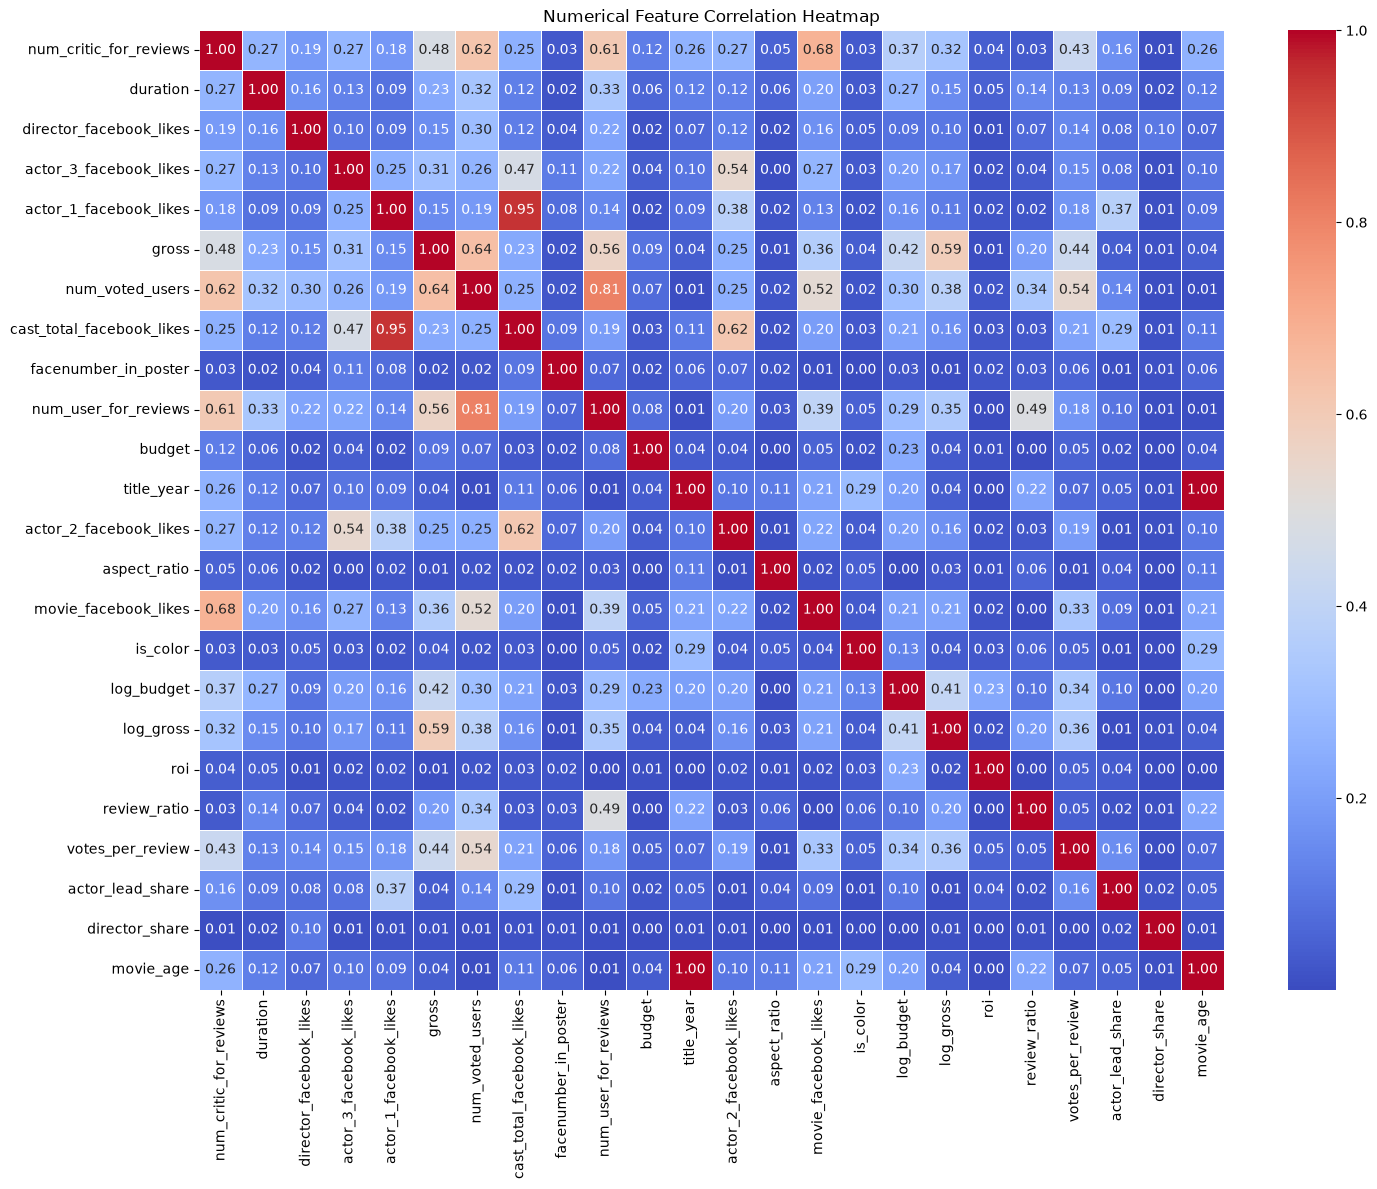

In [7]:
# Feature Scaling (Robust)
scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Correlation Heatmap
corr_matrix = X_train_scaled[num_cols].corr().abs()
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Numerical Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [8]:
# Feature Selection
feature_selector = GradientBoostingClassifier(
    n_estimators=150,
    random_state=42
)

feature_selector.fit(X_train_scaled, y_train)

feature_importance = pd.Series(
    feature_selector.feature_importances_,
    index=X_train_scaled.columns
).sort_values(ascending=False)

N_FEATURES = 30
selected_features = feature_importance.head(N_FEATURES).index.tolist()

print("Original number of features:", X_train_scaled.shape[1])
print("Selected number of features:", len(selected_features))
print("\nSelected Features:")
for feature in selected_features:
    print(feature)

X_train_selected = X_train_scaled[selected_features].copy()
X_test_selected = X_test_scaled[selected_features].copy()

Original number of features: 143
Selected number of features: 30

Selected Features:
num_voted_users
genre_drama
duration
votes_per_review
title_year
budget
log_budget
genre_horror
num_critic_for_reviews
review_ratio
movie_age
genre_documentary
director_name_freq
gross
actor_3_facebook_likes
num_user_for_reviews
roi
genre_action
country_grouped_USA
log_gross
content_rating_grouped_PG-13
actor_lead_share
director_share
actor_2_facebook_likes
cast_total_facebook_likes
movie_facebook_likes
genre_animation
actor_1_facebook_likes
kw_female
genre_comedy


In [9]:
# Multiple Models Setup
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight='balanced'
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss")
}


In [10]:
# Compute sample weights to balance rare classes
sample_weights_train = compute_sample_weight('balanced', y_train)

# Multiple Model Training & Evaluation
results = []

for name, model in models.items():
    if name in ["Gradient Boosting", "AdaBoost", "XGBoost"]:
        model.fit(X_train_selected, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train_selected, y_train)

    y_pred = model.predict(X_test_selected)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average="macro", zero_division=0)
    })

    print("=" * 60)
    print(name)
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
print("\n--- Model Performance Comparison ---")
print(results_df)

Logistic Regression
              precision    recall  f1-score   support

         AVG       0.55      0.62      0.58       305
        FLOP       0.07      0.78      0.13         9
         HIT       0.90      0.73      0.80       686

    accuracy                           0.69      1000
   macro avg       0.51      0.71      0.50      1000
weighted avg       0.79      0.69      0.73      1000

Decision Tree
              precision    recall  f1-score   support

         AVG       0.52      0.59      0.55       305
        FLOP       0.00      0.00      0.00         9
         HIT       0.81      0.76      0.79       686

    accuracy                           0.70      1000
   macro avg       0.44      0.45      0.45      1000
weighted avg       0.71      0.70      0.71      1000

Random Forest
              precision    recall  f1-score   support

         AVG       0.63      0.81      0.71       305
        FLOP       0.67      0.22      0.33         9
         HIT       0.90    

In [11]:
# Cross Validation
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_selected,
        y_train,
        cv=5,
        scoring='f1_macro'
    )
    cv_results[name] = scores

    print("=" * 60)
    print(name)
    print("Cross Validation Macro F1 Scores :", scores)
    print("Mean CV Macro F1 :", scores.mean())
    print("Standard Deviation :", scores.std())

cv_df = pd.DataFrame({
    "Model": cv_results.keys(),
    "CV Macro F1": [np.mean(i) for i in cv_results.values()],
    "CV Std": [np.std(i) for i in cv_results.values()]
}).sort_values("CV Macro F1", ascending=False)

print("\n--- Cross Validation Summary ---")
print(cv_df)


Logistic Regression
Cross Validation Macro F1 Scores : [0.5044119  0.51408046 0.51855224 0.53416866 0.51957381]
Mean CV Macro F1 : 0.5181574143576785
Standard Deviation : 0.009634134852792308
Decision Tree
Cross Validation Macro F1 Scores : [0.50977056 0.49631643 0.46821099 0.49843505 0.45276701]
Mean CV Macro F1 : 0.48510000627791444
Standard Deviation : 0.02117984634043687
Random Forest
Cross Validation Macro F1 Scores : [0.62078214 0.51231486 0.60261524 0.6148856  0.51449208]
Mean CV Macro F1 : 0.5730179853598996
Standard Deviation : 0.0490315392740918
Gradient Boosting
Cross Validation Macro F1 Scores : [0.52411982 0.51283356 0.59464334 0.53774982 0.5276708 ]
Mean CV Macro F1 : 0.5394034674130095
Standard Deviation : 0.02874502716648311
AdaBoost
Cross Validation Macro F1 Scores : [0.46834531 0.4529021  0.48051811 0.46515754 0.49008762]
Mean CV Macro F1 : 0.47140213561631433
Standard Deviation : 0.012828398499921508
XGBoost
Cross Validation Macro F1 Scores : [0.52692188 0.52390242 0

In [12]:
# Hyperparameter Tuning
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train_selected, y_train)

print("\nBest Parameters (Random Forest):", grid.best_params_)
print("Best CV Macro F1 Score:", grid.best_score_)

best_model = grid.best_estimator_
rf_pred = best_model.predict(X_test_selected)


Best Parameters (Random Forest): {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Macro F1 Score: 0.6083133341346849



Tuned Random Forest Final Accuracy: 0.779
              precision    recall  f1-score   support

         AVG       0.61      0.80      0.69       305
        FLOP       0.22      0.22      0.22         9
         HIT       0.90      0.78      0.83       686

    accuracy                           0.78      1000
   macro avg       0.58      0.60      0.58      1000
weighted avg       0.81      0.78      0.79      1000



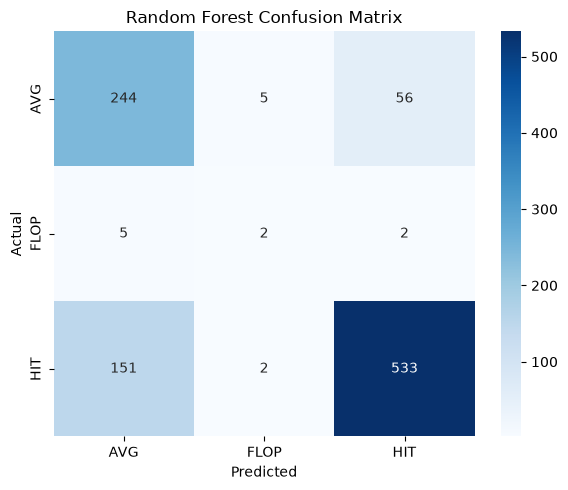

In [13]:
# Model Evaluation
accuracy = accuracy_score(y_test, rf_pred)
print("\nTuned Random Forest Final Accuracy:", accuracy)
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


In [14]:
# Export Artifacts for Streamlit
os.makedirs("models", exist_ok=True)

# Save all trained base models
for name, model in models.items():
    filename = name.replace(" ", "_").lower()
    joblib.dump(model, f"models/{filename}.pkl")

# Save Best Tuned Random Forest
joblib.dump(best_model, "models/best_random_forest.pkl")
joblib.dump(best_model, "models/best_model.pkl")

# Save Preprocessing Encoders, Scalers, and Vectorizers
joblib.dump(label_encoder, "models/label_encoder.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(cv_genres, "models/cv_genres.pkl")
joblib.dump(tfidf_kw, "models/tfidf_kw.pkl")

# Save Feature Information & Lookup Dictionaries
joblib.dump(selected_features, "models/selected_features.pkl")
joblib.dump(freq_lookups, "models/freq_lookups.pkl")
joblib.dump(rare_category_maps, "models/rare_category_maps.pkl")
joblib.dump(num_cols, "models/num_cols.pkl")

# Save Streamlit UI Dropdown Values
category_values = {
    'genres': sorted(list(cv_genres.vocabulary_.keys())),
    'country': df['country'].dropna().unique().tolist(),
    'language': df['language'].dropna().unique().tolist(),
    'content_rating': df['content_rating'].dropna().unique().tolist(),
    'director_name': df['director_name'].dropna().unique().tolist(),
    'actor_1_name': df['actor_1_name'].dropna().unique().tolist(),
    'actor_2_name': df['actor_2_name'].dropna().unique().tolist(),
    'actor_3_name': df['actor_3_name'].dropna().unique().tolist()
}
joblib.dump(category_values, "models/category_values.pkl")
print("\nAll models and Streamlit artifacts saved successfully in 'models/' directory.")


All models and Streamlit artifacts saved successfully in 'models/' directory.
